In [14]:
import numpy as np 
import xarray as xr 
import matplotlib.pyplot as plt 
import torch
from sklearn.model_selection import train_test_split
import torch
import torch.nn.functional as F
from pytorch_tabnet.tab_model import TabNetClassifier
from torch.nn.functional import softmax
from scipy.stats import spearmanr 
import sys

DIR = "/Users/knv2/Documents/codebase/AFL-tutorial/3DPhaseDiagram"
folders = [DIR+"/modules/", DIR+ "/dataset/", DIR+"/benchmarking/v2.0/"]
for path in folders:
    if path not in sys.path:
        sys.path.append(path)

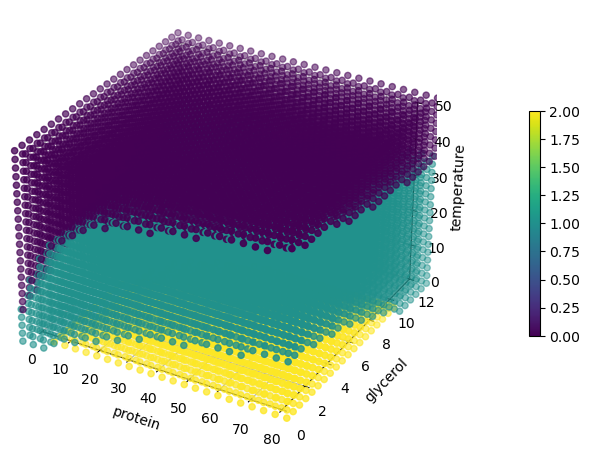

In [15]:
boundary_dataset = xr.load_dataset('../dataset/250610-extrap_expand_dataset.nc')

fig, ax  = plt.subplots(subplot_kw={"projection":'3d'})

ax = ax
mappable = ax.scatter(
    boundary_dataset["composition"].sel(component='protein').values,
    boundary_dataset["composition"].sel(component='glycerol').values,
    boundary_dataset["composition"].sel(component='temperature').values,
    c=boundary_dataset.labels.values
)
ax.set_xlim(0, 80)
ax.set_ylim(0, 12)
ax.set_zlim(0, 50)
cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
ax.set_xlabel("protein")
ax.set_ylabel("glycerol")
ax.set_zlabel("temperature", labelpad=-1)
plt.tight_layout()
plt.show()

In [16]:
X = boundary_dataset["composition"].values.T
y = boundary_dataset.labels.values 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y) 

In [17]:
clf = TabNetClassifier()
clf.load_model("../benchmarking/tabnet.zip")

/Users/knv2/Documents/codebase/envs/3DPhaseDiag/lib/python3.11/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


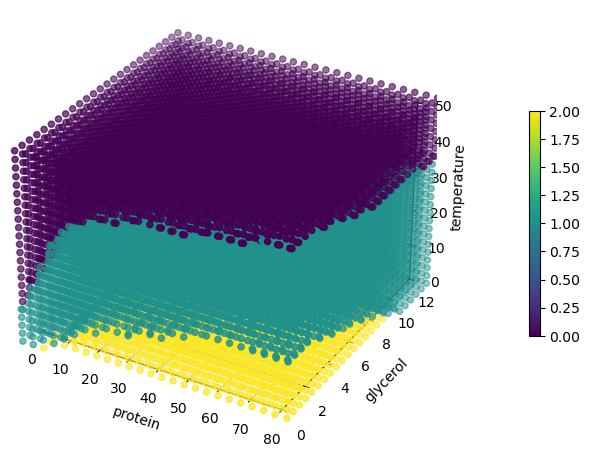

In [18]:
fig, ax  = plt.subplots(subplot_kw={"projection":'3d'})

tabnet_labels = clf.predict(X) 
mappable = ax.scatter(
    boundary_dataset["composition"].sel(component='protein').values,
    boundary_dataset["composition"].sel(component='glycerol').values,
    boundary_dataset["composition"].sel(component='temperature').values,
    c=tabnet_labels
)
ax.set_xlim(0, 80)
ax.set_ylim(0, 12)
ax.set_zlim(0, 50)
cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
ax.set_xlabel("protein")
ax.set_ylabel("glycerol")
ax.set_zlabel("temperature", labelpad=-1)
plt.tight_layout()
plt.show()

In [19]:
ds = xr.load_dataset('../benchmarking/v2.0/results/P5/4/ds_50.nc') 

In [20]:
clf.network.eval()
with torch.no_grad():
    Xt = torch.from_numpy(ds.design_space_grid.values).to(torch.float32)
    logits = clf.network(Xt)[0]
probs = softmax(logits, dim=1).numpy()
eps = 1e-12
entropy = -np.sum(probs * np.log(probs + eps), axis=1)

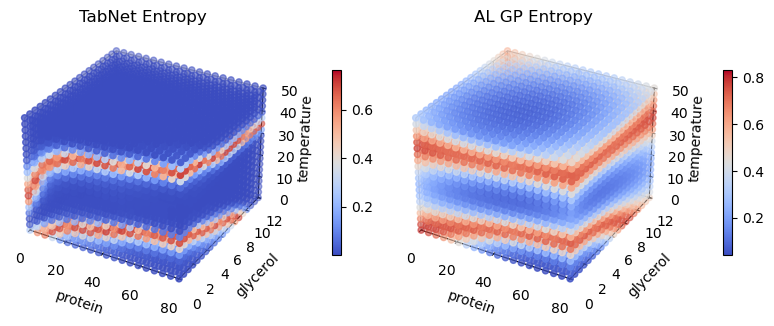

In [56]:
fig, axs  = plt.subplots(1,2, figsize=(4*2, 4), subplot_kw={"projection":'3d'})


axs[0].set_title("TabNet Entropy")
axs[1].set_title("AL GP Entropy")
plot_color_labels = [probs.argmax(axis=1), ds.phase_mean]
plot_color_entropy = [entropy, ds.phase_entropy.values]
for ax, f in zip(axs, plot_color_entropy):
    mappable = ax.scatter(
        ds["design_space_grid"].sel(ds_dim='protein').values,
        ds["design_space_grid"].sel(ds_dim='glycerol').values,
        ds["design_space_grid"].sel(ds_dim='temperature').values,
        c=f,
        cmap="coolwarm"
    )
    ax.set_xlim(0, 80)
    ax.set_ylim(0, 12)
    ax.set_zlim(0, 50)
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
    ax.set_xlabel("protein")
    ax.set_ylabel("glycerol")
    ax.set_zlabel("temperature", labelpad=-1)
plt.tight_layout()
plt.show()

In [22]:
corr, _ = spearmanr(entropy, ds.phase_entropy.values)
print(f"Spearman correlation:{corr:.2f}")

Spearman correlation:0.63


In [51]:
from levelsets import LevelSetFunctionalMapDistance

L = LevelSetFunctionalMapDistance(
    f_grid=probs.argmax(axis=1).reshape(20,20,20), 
    g_grid=ds.phase_mean.values.reshape(20,20,20), 
    c=0.0, 
    k_eig=20, 
    n_hks_times=6, 
    alpha=0.5, 
    beta=0.5
)
L.prepare()
out = L.compute()
print("Output:", out)

Output: {'E_disp': 3443.3266979669515, 'E_shape': 1.8282865186010615e+46, 'E_total': 1.8282865186010615e+46, 'distance': 1.3521414565795479e+23, 'u_mean': 0.893458947930543, 'area_ref': 421.04638877702087}


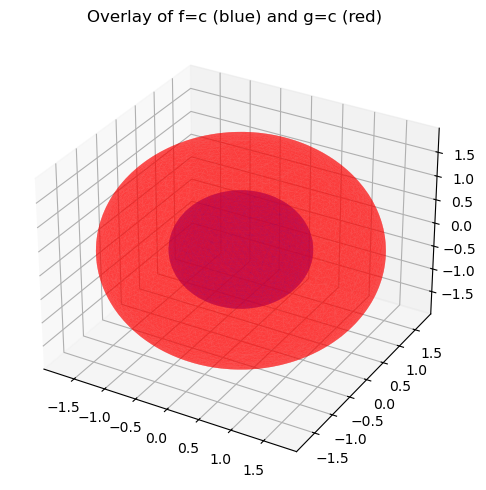

In [47]:
import numpy as np
from skimage import measure
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def visualize_levelsets(grid, f_grid, g_grid, c, overlay=True, alpha=0.5):
    """
    Visualize the level sets f=c and g=c extracted from voxel grids, in true domain coordinates.

    Parameters
    ----------
    grid : ndarray, shape (nx, ny, nz, 3)
        The physical domain coordinates for each voxel center.
        E.g., from np.meshgrid(x, y, z, indexing="ij"), stacked as (..., 3).
    f_grid, g_grid : ndarray, shape (nx, ny, nz)
        Scalar fields defined on the grid.
    c : float
        Levelset value to extract.
    overlay : bool, default=True
        If True, plot both surfaces in the same 3D axis with different colors.
        If False, plot them side-by-side in subplots.
    elev, azim : float
        Viewing angles for 3D plot (matplotlib convention).
    alpha : float
        Transparency of the surfaces.

    Returns
    -------
    fig : matplotlib Figure
        The figure object with the visualization.
    """
    # Extract level sets in index space
    verts_f, faces_f, _, _ = measure.marching_cubes(f_grid, level=c)
    verts_g, faces_g, _, _ = measure.marching_cubes(g_grid, level=c)

    # Convert index-space verts to domain coordinates using the grid
    # Assume grid is structured and uniformly spaced
    nx, ny, nz = f_grid.shape
    xs = grid[:, :, :, 0]
    ys = grid[:, :, :, 1]
    zs = grid[:, :, :, 2]
    dx = (xs[-1, 0, 0] - xs[0, 0, 0]) / (nx - 1)
    dy = (ys[0, -1, 0] - ys[0, 0, 0]) / (ny - 1)
    dz = (zs[0, 0, -1] - zs[0, 0, 0]) / (nz - 1)
    origin = np.array([xs[0, 0, 0], ys[0, 0, 0], zs[0, 0, 0]])

    verts_f_world = verts_f * np.array([dx, dy, dz]) + origin
    verts_g_world = verts_g * np.array([dx, dy, dz]) + origin

    # Plot
    fig = plt.figure(figsize=(10, 5))
    if overlay:
        ax = fig.add_subplot(111, projection="3d")
        mesh_f = Poly3DCollection(verts_f_world[faces_f], alpha=alpha, facecolor="blue")
        mesh_g = Poly3DCollection(verts_g_world[faces_g], alpha=alpha, facecolor="red")
        ax.add_collection3d(mesh_f)
        ax.add_collection3d(mesh_g)
        ax.set_title("Overlay of f=c (blue) and g=c (red)")
    else:
        ax1 = fig.add_subplot(121, projection="3d")
        mesh_f = Poly3DCollection(verts_f_world[faces_f], alpha=alpha, facecolor="blue")
        ax1.add_collection3d(mesh_f)
        ax1.set_title("f=c")

        ax2 = fig.add_subplot(122, projection="3d")
        mesh_g = Poly3DCollection(verts_g_world[faces_g], alpha=alpha, facecolor="red")
        ax2.add_collection3d(mesh_g)
        ax2.set_title("g=c")

        ax = ax1

    # Set axis limits from combined verts
    all_verts = np.vstack([verts_f_world, verts_g_world])
    mins = all_verts.min(axis=0)
    maxs = all_verts.max(axis=0)
    for axis in fig.axes:
        if hasattr(axis, "set_xlim"):
            axis.set_xlim(mins[0], maxs[0])
            axis.set_ylim(mins[1], maxs[1])
            axis.set_zlim(mins[2], maxs[2])

    plt.tight_layout()
    return fig, ax


nx = ny = nz = 64
x = np.linspace(-3, 3, nx)
y = np.linspace(-3, 3, ny)
z = np.linspace(-3, 3, nz)
X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
grid = np.stack([X, Y, Z], axis=-1)

R = np.sqrt(X**2 + Y**2 + Z**2)
f_grid = R - 1.0
g_grid = R - 2.0

fig,_ = visualize_levelsets(grid, f_grid, g_grid, c=0.0, overlay=True)
plt.show()

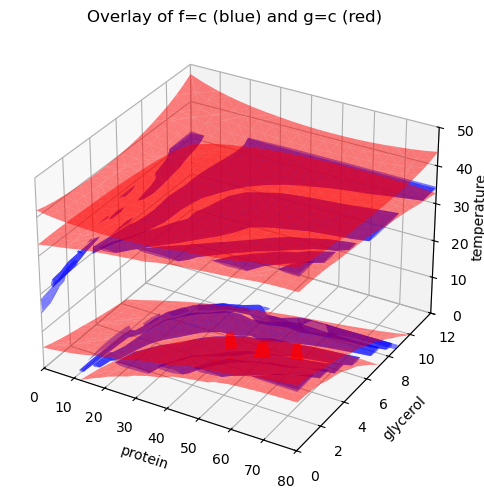

In [61]:
x = np.linspace(0.0, 80.0, 20)
y = np.linspace(0.0, 12.0, 20)
z = np.linspace(0.0, 50.0, 20)
X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
grid = np.stack([X, Y, Z], axis=-1)

fig, ax = visualize_levelsets(
    grid,
    f_grid=entropy.reshape(20,20,20), 
    g_grid=ds.phase_entropy.values.reshape(20,20,20), 
    c=0.65, 
    overlay=True,
)
ax.set_xlim(0, 80)
ax.set_ylim(0, 12)
ax.set_zlim(0, 50)
ax.set_xlabel("protein")
ax.set_ylabel("glycerol")
ax.set_zlabel("temperature", labelpad=-1)
plt.tight_layout()
plt.show()